In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('ggplot') 


In [5]:
df = pd.read_csv('C:/Users/HP/OneDrive/Desktop/Zomato-Restaurant-Analytics/data/zomato.csv')

df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [6]:
df.shape

(51717, 17)

In [7]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [8]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
drop_cols = ['url', 'phone', 'menu_item', 'reviews_list']

df.drop(columns=drop_cols, inplace=True) 


In [11]:
df.dropna(inplace=True)

In [12]:
df = df[df['rate'] != 'NEW']
df = df[df['rate'] != '-']

In [13]:
df['rate'] = df['rate'].apply(lambda x: x.split('/')[0])

df['rate'] = df['rate'].astype(float)

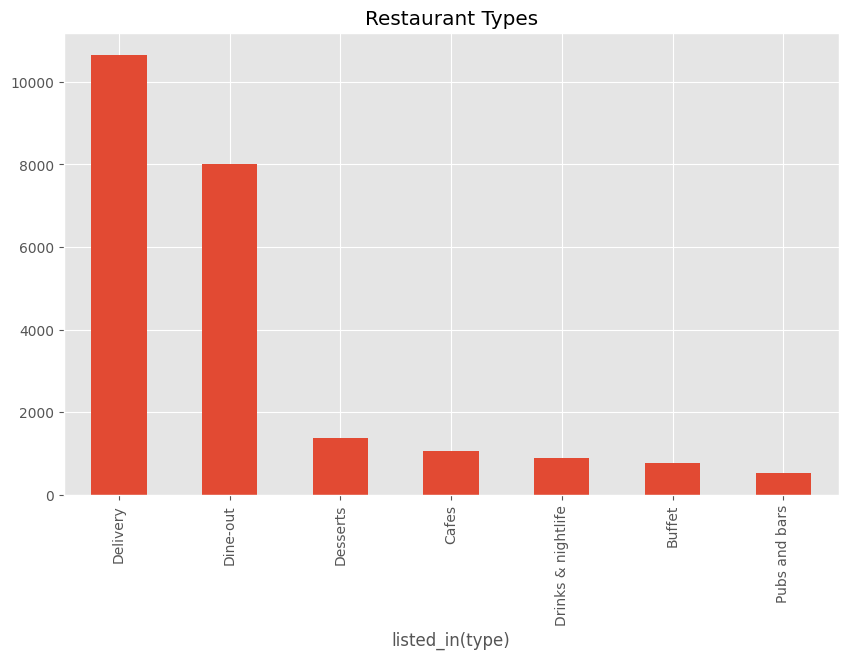

In [14]:
plt.figure(figsize=(10,6))
df['listed_in(type)'].value_counts().plot(kind='bar')
plt.title('Restaurant Types')
plt.show()

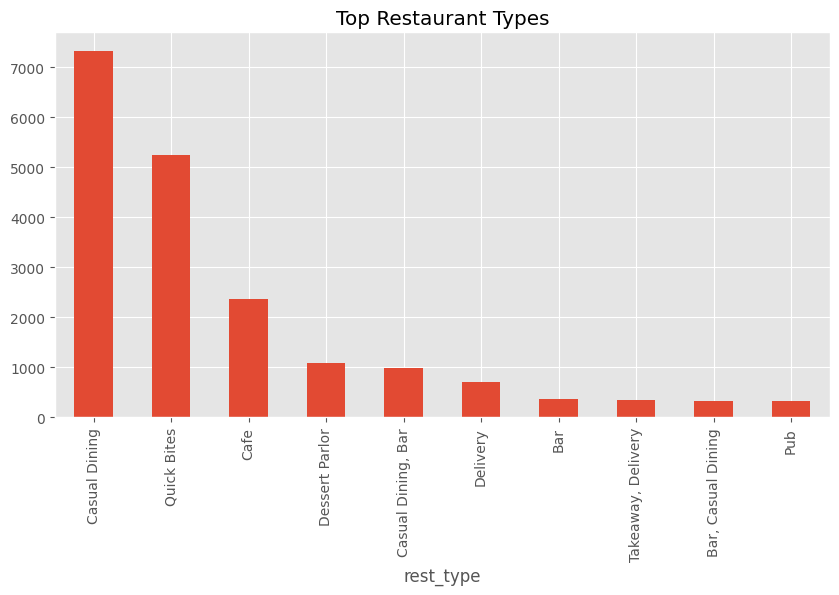

In [16]:
plt.figure(figsize=(10,5))
df['rest_type'].value_counts().head(10).plot(kind='bar')
plt.title("Top Restaurant Types")
plt.show()

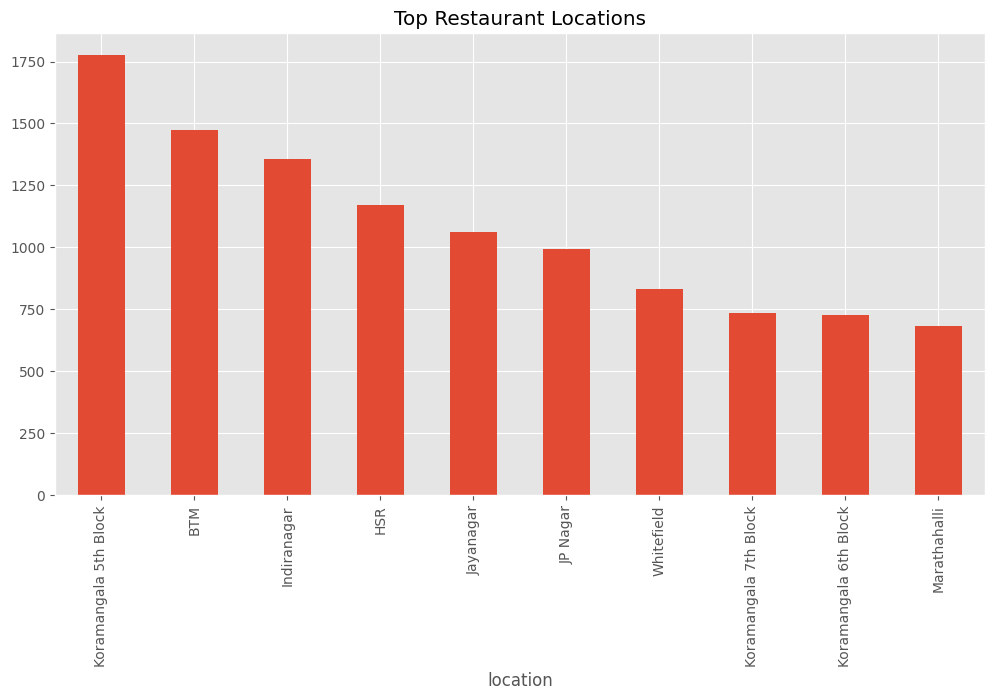

In [17]:
plt.figure(figsize=(12,6))
df['location'].value_counts().head(10).plot(kind='bar')
plt.title("Top Restaurant Locations")
plt.show()

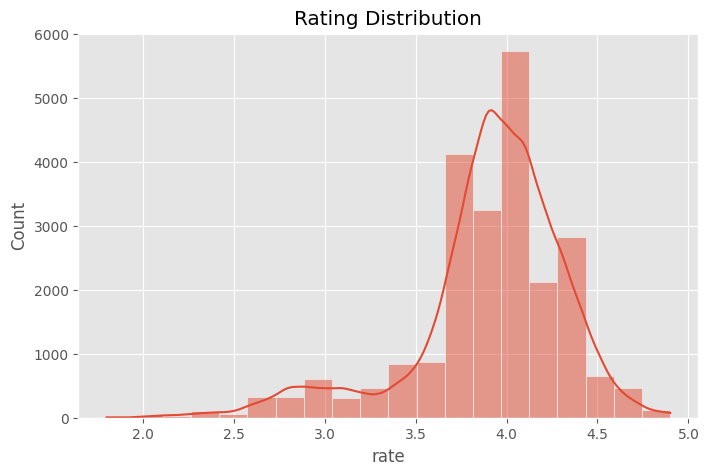

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['rate'], bins=20, kde=True)
plt.title("Rating Distribution")
plt.show()

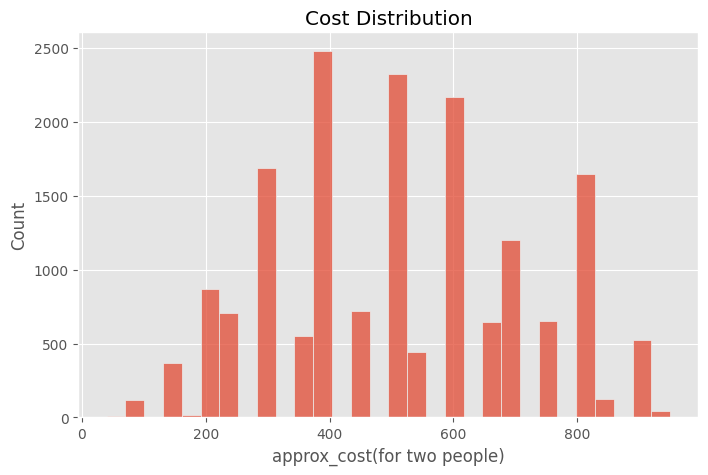

In [19]:
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'], errors='coerce'
)

plt.figure(figsize=(8,5))
sns.histplot(df['approx_cost(for two people)'].dropna(), bins=30)
plt.title("Cost Distribution")
plt.show()

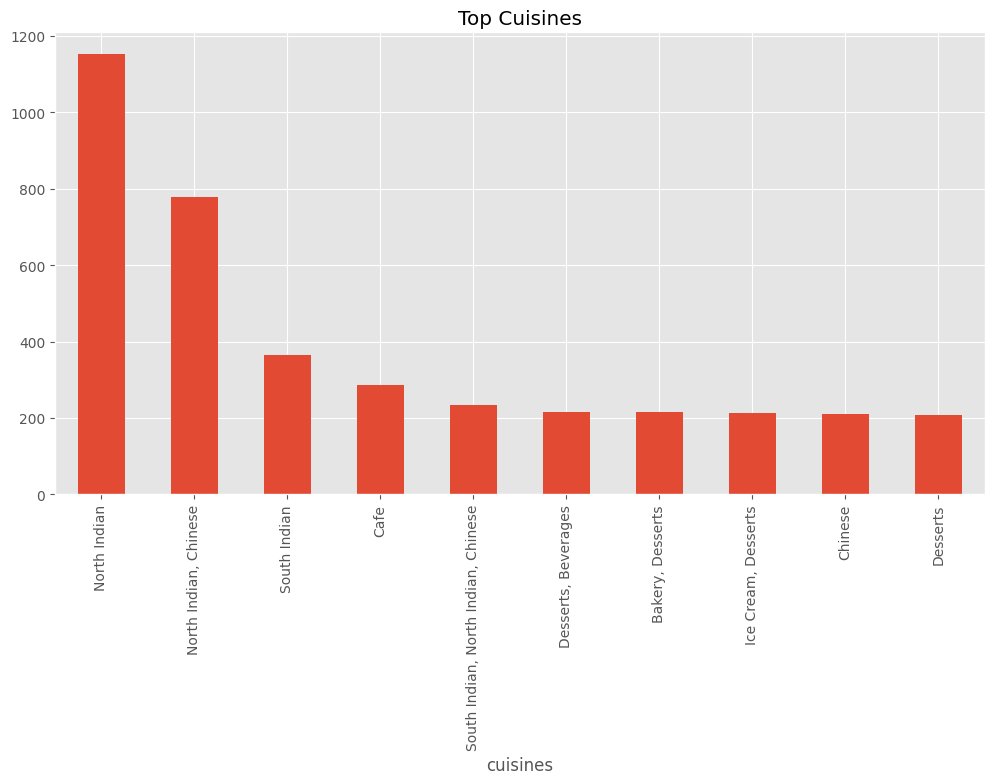

In [20]:
plt.figure(figsize=(12,6))
df['cuisines'].value_counts().head(10).plot(kind='bar')
plt.title("Top Cuisines")
plt.show()

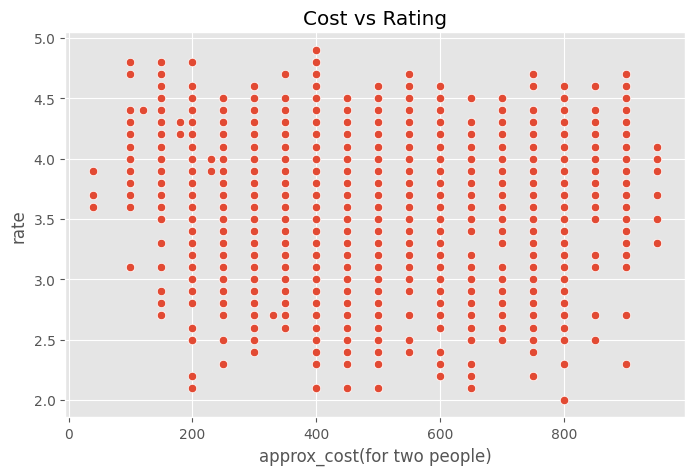

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='approx_cost(for two people)', y='rate', data=df)
plt.title("Cost vs Rating")
plt.show()

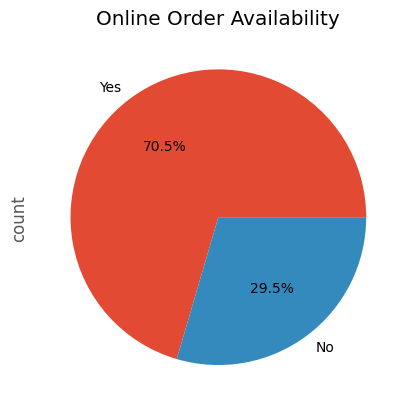

In [22]:
df['online_order'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Online Order Availability")
plt.show()

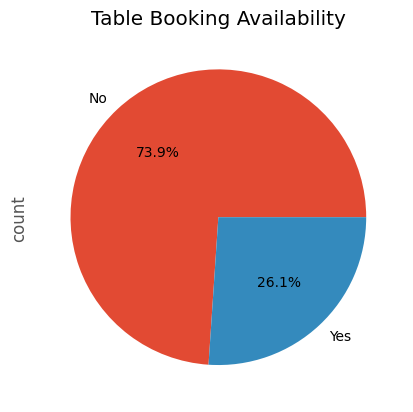

In [23]:
df['book_table'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Table Booking Availability")
plt.show()

In [24]:
df.sort_values(by='rate', ascending=False)[['name','rate']].head(10)

,name,rate
39559,Punjab Grill,4.9
7888,Flechazo,4.9
27453,Asia Kitchen By Mainland China,4.9
46960,Punjab Grill,4.9
45812,SantÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃ...,4.9
46253,Punjab Grill,4.9
14740,Belgian Waffle Factory,4.9
23587,AB's - Absolute Barbecues,4.9
47409,Belgian Waffle Factory,4.9
3921,Byg Brewski Brewing Company,4.9


In [25]:
df.groupby('location')['rate'].mean().sort_values(ascending=False).head(10)

location
Lavelle Road             4.193274
Koramangala 5th Block    4.151351
Sankey Road              4.105882
Koramangala 3rd Block    4.100617
Cunningham Road          4.100300
St. Marks Road           4.099013
Koramangala 2nd Block    4.073333
Sadashiv Nagar           4.061538
Residency Road           4.051584
Church Street            4.045898
Name: rate, dtype: float64

In [26]:
df.groupby('rest_type')['approx_cost(for two people)'].mean().sort_values(ascending=False).head(10)

rest_type
Pub                      900.000000
Casual Dining, Lounge    900.000000
Casual Dining, Pub       900.000000
Bar, Casual Dining       862.500000
Bar, Pub                 850.000000
Casual Dining, Bar       770.689655
Cafe, Casual Dining      767.777778
Bar                      711.111111
Casual Dining, Cafe      704.522613
Casual Dining            658.522727
Name: approx_cost(for two people), dtype: float64